# Stationarity Analysis — Nifty 50

## What this project covers
Time series stationarity analysis on real Nifty 50 data (2019-2023).

## Key concepts
- Raw stock prices are NON-stationary — trending mean, changing variance
- Daily returns ARE stationary — constant mean near 0, stable variance
- ADF test mathematically confirms what eyes can see visually

## Results
- Prices ADF p-value: 0.9398 → NOT STATIONARY
- Returns ADF p-value: 0.0000 → STATIONARY

## Real world insight
Always model returns, never raw prices.
Volatility clustering visible during COVID crash (2020).

## Libraries used
- yfinance — real market data
- statsmodels — ADF test
- pandas, matplotlib — analysis and visualization

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Download Nifty 50 data — last 5 years
# ^NSEI is the Yahoo Finance ticker for Nifty 50

nifty = yf.download("^NSEI", start="2019-01-01", end="2024-01-01")

# We only need the closing price
prices = nifty['Close']

print(f"Total trading days: {len(prices)}")
print(f"First date: {prices.index[0].date()}")
print(f"Last date: {prices.index[-1].date()}")
print(f"Starting price: {float(prices.iloc[0]):.2f}")
print(f"Ending price: {float(prices.iloc[-1]):.2f}")

[*********************100%***********************]  1 of 1 completed

Total trading days: 1232
First date: 2019-01-02
Last date: 2023-12-29
Starting price: 10792.50
Ending price: 21731.40



/var/folders/77/ljf0pc6d5l14ft71759h4qrw0000gn/T/ipykernel_2374/626485332.py:17: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"Starting price: {float(prices.iloc[0]):.2f}")
/var/folders/77/ljf0pc6d5l14ft71759h4qrw0000gn/T/ipykernel_2374/626485332.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"Ending price: {float(prices.iloc[-1]):.2f}")


<Figure size 1200x500 with 0 Axes>

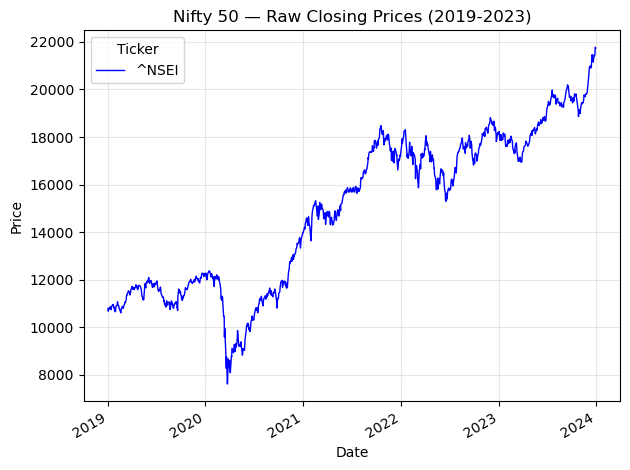

In [3]:
# Plot raw Nifty 50 prices
# Just by looking at this we can already tell if it's stationary or not

plt.figure(figsize=(12, 5))
prices.plot(color='blue', linewidth=1)
plt.title('Nifty 50 — Raw Closing Prices (2019-2023)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

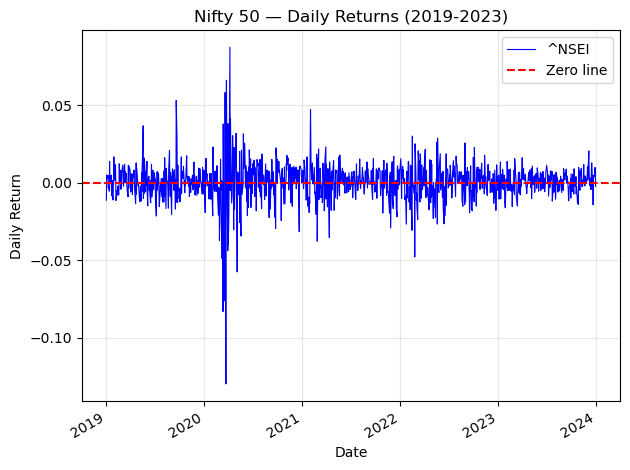

Mean return: 0.000642
Std deviation: 0.012040


In [4]:
# Transform prices to daily returns
# Return = (today's price - yesterday's price) / yesterday's price
# This is the standard transformation to achieve stationarity

returns = prices.pct_change().dropna()

# Plot returns
plt.figure(figsize=(12, 5))
returns.plot(color='blue', linewidth=0.8)
plt.axhline(y=0, color='red', linewidth=1.5, linestyle='--', label='Zero line')
plt.title('Nifty 50 — Daily Returns (2019-2023)')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean return: {returns.mean().values[0]:.6f}")
print(f"Std deviation: {returns.std().values[0]:.6f}")

In [5]:
from statsmodels.tsa.stattools import adfuller

# Run ADF test on prices first
result_prices = adfuller(prices.dropna())

print("=== ADF Test on Raw Prices ===")
print(f"ADF Statistic: {result_prices[0]:.4f}")
print(f"p-value: {result_prices[1]:.4f}")
print(f"Conclusion: {'STATIONARY' if result_prices[1] < 0.05 else 'NOT STATIONARY'}")

print()

# Run ADF test on returns
result_returns = adfuller(returns.dropna())

print("=== ADF Test on Daily Returns ===")
print(f"ADF Statistic: {result_returns[0]:.4f}")
print(f"p-value: {result_returns[1]:.4f}")
print(f"Conclusion: {'STATIONARY' if result_returns[1] < 0.05 else 'NOT STATIONARY'}")

=== ADF Test on Raw Prices ===
ADF Statistic: -0.1888
p-value: 0.9398
Conclusion: NOT STATIONARY

=== ADF Test on Daily Returns ===
ADF Statistic: -10.3033
p-value: 0.0000
Conclusion: STATIONARY


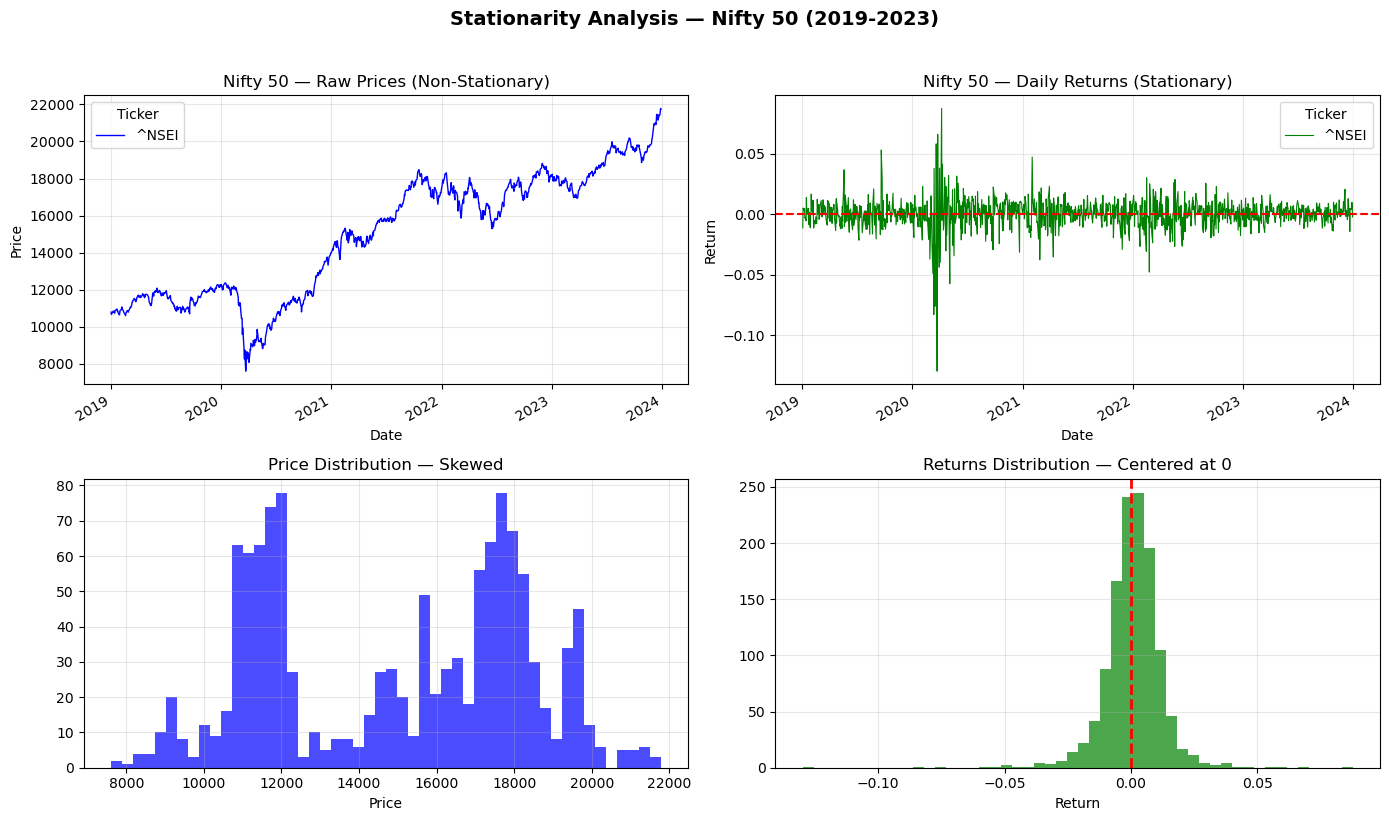

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Raw prices plot
prices.plot(ax=axes[0,0], color='blue', linewidth=1)
axes[0,0].set_title('Nifty 50 — Raw Prices (Non-Stationary)')
axes[0,0].set_ylabel('Price')
axes[0,0].grid(True, alpha=0.3)

# Returns plot
returns.plot(ax=axes[0,1], color='green', linewidth=0.8)
axes[0,1].axhline(y=0, color='red', linewidth=1.5, linestyle='--')
axes[0,1].set_title('Nifty 50 — Daily Returns (Stationary)')
axes[0,1].set_ylabel('Return')
axes[0,1].grid(True, alpha=0.3)

# Price distribution
axes[1,0].hist(prices.values.flatten(), bins=50, color='blue', alpha=0.7)
axes[1,0].set_title('Price Distribution — Skewed')
axes[1,0].set_xlabel('Price')
axes[1,0].grid(True, alpha=0.3)

# Returns distribution
axes[1,1].hist(returns.values.flatten(), bins=50, color='green', alpha=0.7)
axes[1,1].axvline(x=0, color='red', linewidth=2, linestyle='--')
axes[1,1].set_title('Returns Distribution — Centered at 0')
axes[1,1].set_xlabel('Return')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Stationarity Analysis — Nifty 50 (2019-2023)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()